## Is the NVS distribution Boltzmann for the RWA oscillators?

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import diffrax
import matplotlib.pyplot as plt
from functools import partial

from diffrax import ControlTerm, MultiTerm, ODETerm, PIDController

jax.config.update("jax_enable_x64", True)

In [2]:
# ----------------------------
# 1. Define Parameters
# ----------------------------

# System Physical Parameters
M = 1.0                # Mass (arbitrary units)
w_0 = 1.0             # Natural frequency (rad/s)
Qual = 50.0         # Quality factor of the oscillator
gamma = 0.06         # Nonlinearity coefficient (Duffing term)

# Driving Forces Parameters
w_p = 2*w_0          # Parametric driving frequency (rad/s), set to 2*w_0 for parametric resonance
F_p = 0.5          # Amplitude of parametric driving
F = 0.00              # Amplitude of direct driving
w_F = w_0            # Frequency of direct driving (rad/s)

# Thermal Parameters
k_B = 1.0            # Boltzmann's constant (arbitrary units)
T = 2.            # Temperature (K) - currently set to 0

# Time and Simulation Parameters
period = 2*jnp.pi/w_0        # Natural period of oscillation
t0 = 0.0                     # Start time
num_periods = 100000            # Number of periods to simulate
t1 = num_periods*period      # End time
dt0 = period/1000           # Initial time step
num_pts_per_period = 100    # Number of points per period
ts_dim = jnp.linspace(t0, t1, num_periods*num_pts_per_period)



CUDA backend failed to initialize: Unable to use CUDA because of the following issues with CUDA components:
Outdated cuDNN installation found.
Version JAX was built against: 8907
Minimum supported: 9100
Installed version: 8907
The local installation version must be no lower than 9100..(Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [3]:
def Hamiltonian(t,Q, P):
    dw = w_p/2 - w_0
    return 3*gamma/(32*w_0) * (Q**2 + P**2)**2 + dw/2 *(Q**2 - P**2) +  F_p/(8*M*w_0) * (P**2 - Q**2) - F*Q/(2*M*w_0)

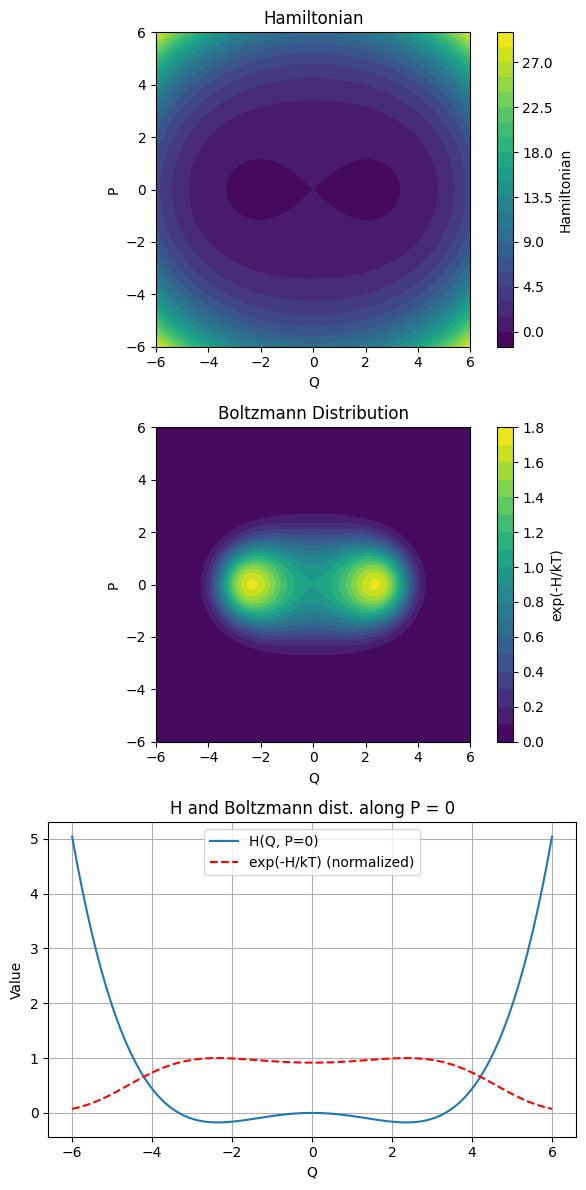

In [4]:
# Plot the Hamiltonian and Boltzmann distribution
Q_range = jnp.linspace(-2, 2, 100)*3
P_range = jnp.linspace(-2, 2, 100)*3
# Create meshgrid for Q and P
Q_mesh, P_mesh = jnp.meshgrid(Q_range, P_range)

# Vectorize Hamiltonian over both Q and P meshgrids
H_values = jax.vmap(lambda q, p: jax.vmap(lambda qi, pi: Hamiltonian(0.,qi, pi))(q, p))(Q_mesh, P_mesh)

# Calculate Boltzmann distribution
boltz_values = jnp.exp(-H_values/(k_B * T/(2*jnp.pi)))

# Create figure with three subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(6, 12))

# Create Hamiltonian contour plot
contour1 = ax1.contourf(Q_range, P_range, H_values, levels=20, cmap='viridis')
plt.colorbar(contour1, ax=ax1, label='Hamiltonian')
ax1.set_aspect('equal')
ax1.set_xlabel('Q')
ax1.set_ylabel('P')
ax1.set_title('Hamiltonian')

# Create Boltzmann distribution contour plot
contour2 = ax2.contourf(Q_range, P_range, boltz_values, levels=20, cmap='viridis')
plt.colorbar(contour2, ax=ax2, label='exp(-H/kT)')
ax2.set_aspect('equal')
ax2.set_xlabel('Q')
ax2.set_ylabel('P')
ax2.set_title('Boltzmann Distribution')

# Plot P = 0 line for both
H_P0 = jnp.array([Hamiltonian(0., q, 0.) for q in Q_range])
boltz_P0 = jnp.exp(-H_P0/(k_B * T))

ax3.plot(Q_range, H_P0, label='H(Q, P=0)')
ax3.plot(Q_range, boltz_P0/jnp.max(boltz_P0), '--', label='exp(-H/kT) (normalized)', color='red')
ax3.set_xlabel('Q')
ax3.set_ylabel('Value')
ax3.set_title('H and Boltzmann dist. along P = 0')
ax3.grid(True)
ax3.legend()

plt.tight_layout()
plt.show()

In [5]:
# # Amplitude Equations SDEs for RWA
def drift_QP_fn(t, state, args):
    """
    Drift function 
    """
    Q, P = state
        
    H = lambda _Q, _P: Hamiltonian(t,_Q, _P)
    
    dQdt =  jax.grad(H, 1)(Q, P) - w_0/(2*Qual)*Q
    dPdt = -jax.grad(H, 0)(Q, P) - w_0/(2*Qual)*P
    
    # Drift terms
    return jnp.array([dQdt, dPdt])



def diffusion_QP_fn(t, state, args):
    """
    Diffusion matrix for Q and P equations.
    Returns a 2x2 matrix where diagonal terms represent independent noise for Q and P.
    """
    noise_strength_QP =  jnp.sqrt(2*(w_0/(2*Qual))*k_B * T/(M*w_0**2))  
    return noise_strength_QP * jnp.eye(2) 



In [6]:

w_shape = (2,)  # state is (Q, P)
brownian_motion_QP = diffrax.VirtualBrownianTree(
    t0, t1, 1.e-11, w_shape, jr.PRNGKey(0), diffrax.SpaceTimeLevyArea
)

y0_QP = jnp.array([1, 0.0])

terms_QP = MultiTerm(ODETerm(drift_QP_fn), ControlTerm(diffusion_QP_fn, brownian_motion_QP))

saveat = diffrax.SaveAt(ts=ts_dim)

solution_QP = diffrax.diffeqsolve(
    terms_QP,
    solver=diffrax.SRA1(),
    t0=t0,
    t1=t1,
    dt0=dt0,
    y0=y0_QP,
    args=(),
    saveat=saveat,
    progress_meter=diffrax.TqdmProgressMeter(),
    max_steps=1000000000000,
    stepsize_controller=diffrax.PIDController(rtol=1e-3, atol=1e-6),  # Enable adaptive stepping
)
sde_samples_QP = solution_QP.ys



/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.Dynami

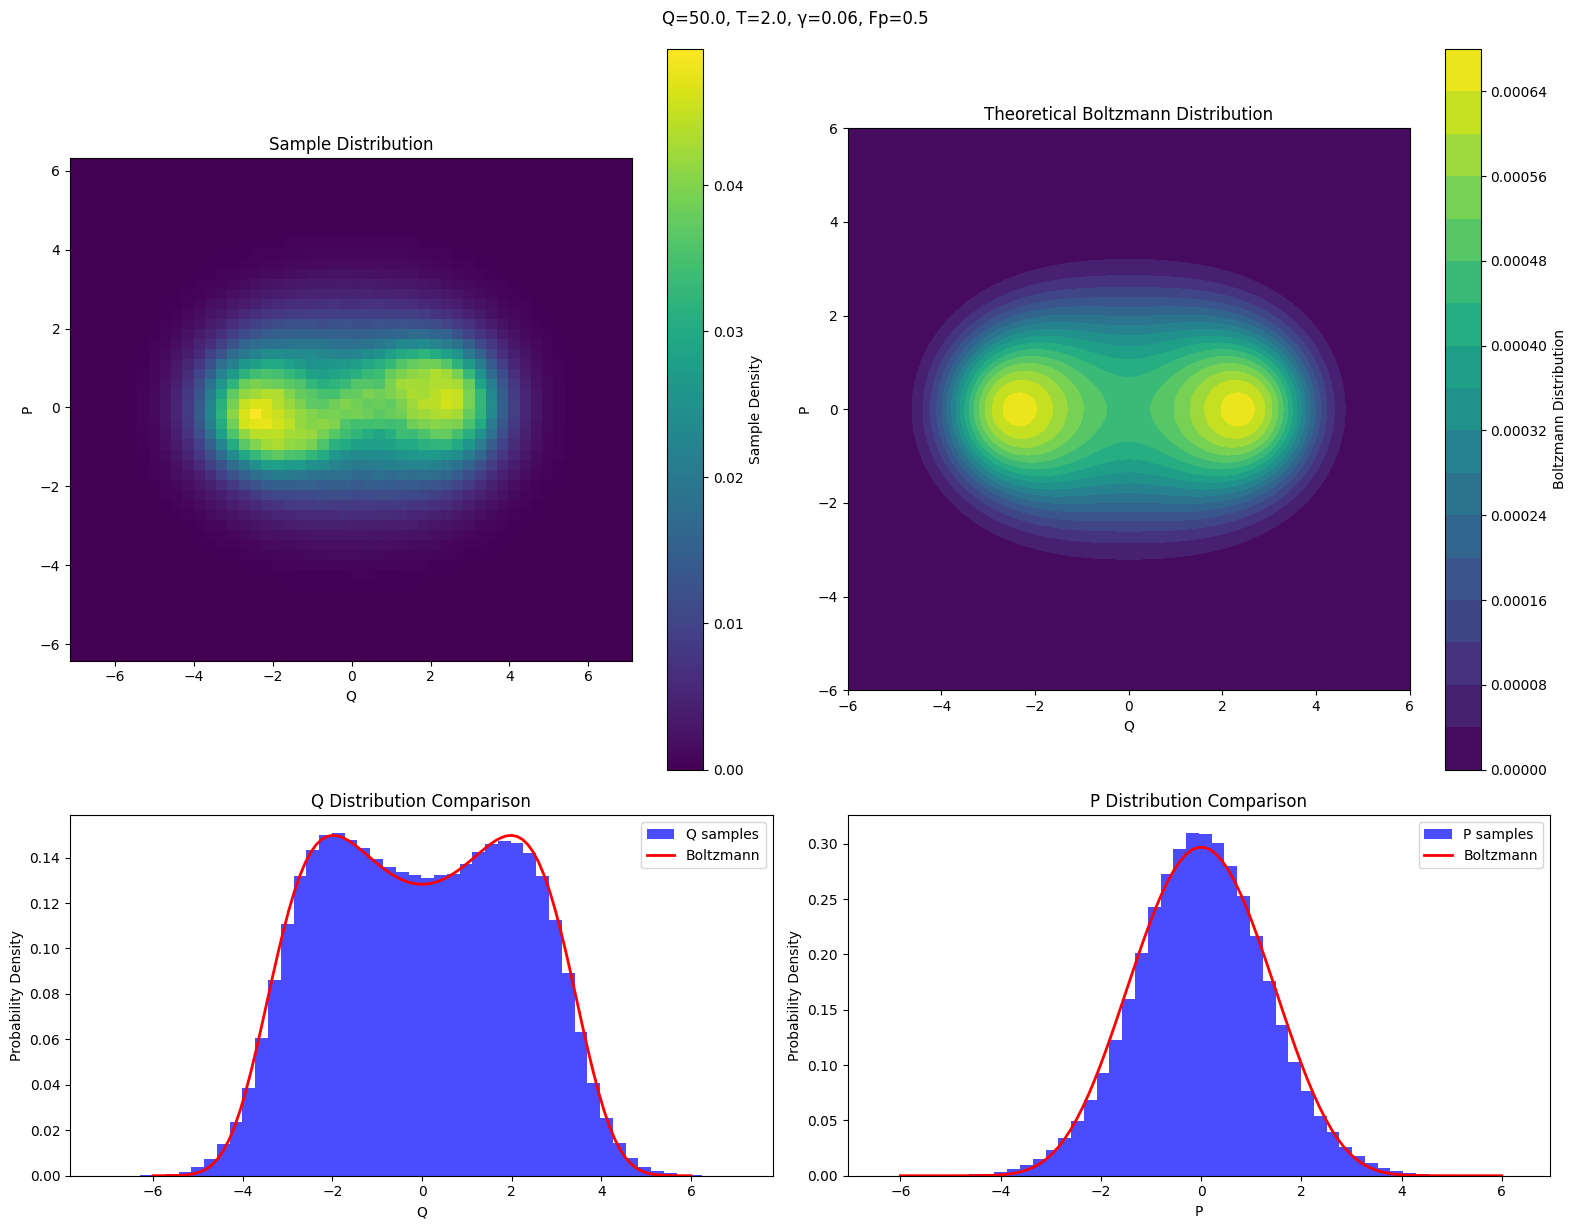

In [9]:
boltz_values = jnp.exp(-H_values/(k_B * T/(4)))
# Create figure with a grid of subplots
fig = plt.figure(figsize=(16, 12))
gs = plt.GridSpec(2, 2, height_ratios=[2, 1])

# Top left: Phase space density plot of samples
ax1 = fig.add_subplot(gs[0, 0])
h = ax1.hist2d(sde_samples_QP[:, 0], sde_samples_QP[:, 1], bins=50, density=True)
plt.colorbar(h[3], ax=ax1, label='Sample Density')
ax1.set_aspect('equal')
ax1.set_xlabel('Q')
ax1.set_ylabel('P')
ax1.set_title('Sample Distribution')

# Top right: Theoretical Boltzmann distribution
ax2 = fig.add_subplot(gs[0, 1])
contour = ax2.contourf(Q_range, P_range, boltz_values/jnp.sum(boltz_values), 
                      levels=20, cmap='viridis')
plt.colorbar(contour, ax=ax2, label='Boltzmann Distribution')
ax2.set_aspect('equal')
ax2.set_xlabel('Q')
ax2.set_ylabel('P')
ax2.set_title('Theoretical Boltzmann Distribution')

# Bottom: Comparison of marginal distributions
# Q distribution
ax3 = fig.add_subplot(gs[1, 0])
# Histogram of samples
ax3.hist(sde_samples_QP[:, 0], bins=50, density=True, alpha=0.7, 
         label='Q samples', color='blue')
# Theoretical marginal distribution
Q_marginal = jnp.sum(boltz_values, axis=0)
Q_marginal = Q_marginal/jnp.sum(Q_marginal)*(len(Q_range)-1)/(Q_range[-1]-Q_range[0])
ax3.plot(Q_range, Q_marginal, 'r-', label='Boltzmann', linewidth=2)
ax3.set_xlabel('Q')
ax3.set_ylabel('Probability Density')
ax3.set_title('Q Distribution Comparison')
ax3.legend()

# P distribution
ax4 = fig.add_subplot(gs[1, 1])
# Histogram of samples
ax4.hist(sde_samples_QP[:, 1], bins=50, density=True, alpha=0.7, 
         label='P samples', color='blue')
# Theoretical marginal distribution
P_marginal = jnp.sum(boltz_values, axis=1)
P_marginal = P_marginal/jnp.sum(P_marginal)*(len(P_range)-1)/(P_range[-1]-P_range[0])
ax4.plot(P_range, P_marginal, 'r-', label='Boltzmann', linewidth=2)
ax4.set_xlabel('P')
ax4.set_ylabel('Probability Density')
ax4.set_title('P Distribution Comparison')
ax4.legend()

plt.tight_layout()
# Add title with parameters
title = f'Q={Qual}, T={T}, γ={gamma}, Fp={F_p}'
plt.suptitle(title, y=1.02)


import os

# Create the directory if it doesn't exist
save_dir = "../out/UnderstandingDistribution/"
os.makedirs(save_dir, exist_ok=True)

# Then save the figure
# filename = f'comparison_sim_to_BM_Q{Qual}_T{T}_gamma{gamma}_Fp{F_p}_num_samples_{num_periods*num_pts_per_period}'.replace('.', 'p') + '.png'
# full_path = os.path.join(save_dir, filename)
# plt.savefig(full_path, bbox_inches='tight', dpi=300)